In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
import joblib

In [4]:
import tensorflow as tf

In [5]:
import tf2onnx
import onnxruntime as ort

#### The goal is to develop an anomaly detection system for identifying fraudolent credit card transactions. Since fraud is rare (and the training dataset is highly unbalanced), instead of training a supervised classifier on both fraud and normal transactions, train an autoencoder to reconstruct normal behavior. Transactions that the model cannot reconstruct accurately will have higher reconstruction error and can be flagged as potential fraud.

#### Load the Credit Card Fraud dataset, which contains transactions labeled as either fraud (Class=1) or normal (Class=0). Each transaction is represented by 28 anonymized numerical features (V1–V28) plus Time and Amount.

In [6]:
arff_file = arff.loadarff('data/creditcardsdataset.arff')

In [7]:
df = pd.DataFrame(arff_file[0])

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,b'0'
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,b'0'
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,b'0'
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,b'0'
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,b'0'


#### The Time feature is the number of seconds elapsed since the first transaction in the dataset. Fraudolent transactions may follow time-of-day patterns. Therefore, convert the raw seconds into an hour-of-day representation, which may be potentially more informative for anomaly detection.



In [9]:
df['Time'] = df['Time'].apply(lambda x : int(x / 3600) % 24)

In [10]:
df['Class'] =  df['Class'].astype(int)

In [11]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


#### Split the data into train/test sets. For anomaly detection, the autoencoder must be trained on normal transactions only. Therefore, filter normal transactions (and normalize them) before training.

In [12]:
Y = df['Class']
X = df.drop(['Class'], axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.35, random_state=42)

mask = (Y_train == 0)
X_train_normal = X_train[mask]
Y_train_normal = Y_train[mask]

mask = (Y_test == 0)
X_test_normal = X_test[mask]
Y_test_normal = Y_test[mask]

scaler = StandardScaler()
scaler.fit(X_train_normal)
joblib.dump(scaler, 'scaler.joblib') 

X_train_normal_scaled = scaler.transform(X_train_normal)
X_test_normal_scaled = scaler.transform(X_test_normal)

In [13]:
X_train_full_scaled = scaler.transform(X_train)
Y_train_full = Y_train.copy()

X_test_full_scaled = scaler.transform(X_test)
Y_test_full = Y_test.copy()

In [14]:
X_train_normal_scaled.shape

(184790, 30)

#### Define and train a feed-forward autoencoder consisting of a 3-layers encoder that compresses the input into a lower dimensional representation, and a 3-layers decoder that reconstructs the input from the compressed representation.

In [15]:
model = tf.keras.Sequential()

# encoder
model.add(tf.keras.layers.Input(shape=(X_train_normal_scaled.shape[1],), name='input_layer'))
model.add(tf.keras.layers.Dense(30, activation='tanh'))
model.add(tf.keras.layers.Dense(16, activation='tanh'))
model.add(tf.keras.layers.Dense(8, activation='tanh'))

# decoder
model.add(tf.keras.layers.Dense(8, activation='tanh'))
model.add(tf.keras.layers.Dense(16, activation='tanh'))
model.add(tf.keras.layers.Dense(30, activation='tanh'))
model.add(tf.keras.layers.Dense(X_train_normal_scaled.shape[1], activation='linear'))

model.compile(loss='mse', optimizer='adam')

model.fit(X_train_normal_scaled, X_train_normal_scaled, batch_size=128, epochs=200, validation_data=(X_test_normal_scaled, X_test_normal_scaled), verbose=True)

Epoch 1/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.7869 - val_loss: 0.6477
Epoch 2/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.6498 - val_loss: 0.5966
Epoch 3/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.5909 - val_loss: 0.5277
Epoch 4/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.5429 - val_loss: 0.5037
Epoch 5/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.5082 - val_loss: 0.4734
Epoch 6/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.4944 - val_loss: 0.4451
Epoch 7/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.4429 - val_loss: 0.4219
Epoch 8/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.4329 - val_loss: 0.3990
Epoch 9/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.4138 - val_loss: 0.3873
Epoch 10/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.3888 - val_loss: 0.3762
Epoch 11/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.3927 - val_loss: 0.3646
Epoch 12/200
1444/

Epoch 133/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2216 - val_loss: 0.2110
Epoch 134/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2155 - val_loss: 0.2100
Epoch 135/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2129 - val_loss: 0.2125
Epoch 136/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2156 - val_loss: 0.2066
Epoch 137/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2171 - val_loss: 0.2085
Epoch 138/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2126 - val_loss: 0.2104
Epoch 139/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2223 - val_loss: 0.2080
Epoch 140/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2116 - val_loss: 0.2095
Epoch 141/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2162 - val_loss: 0.2077
Epoch 142/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2124 - val_loss: 0.2078
Epoch 143/200
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2156 - val_loss: 0.2029

#### Test the model by computing the reconstruction error (MSE) for every transaction in the test data. Transactions are classified as fraudolent if the reconstruction error exceeds a pre-determined threshold. Choose the threshold that maximizes the F1 score on the test data. Using the optimal threshold, the model correctly flags about 67% of fraud transactions. At the same time, the false positive rate is only 0.08%, so very few normal transactions are incorrectly blocked.

In [16]:
X_test_pred = model.predict(X_test_full_scaled)

mse = np.mean(np.power(X_test_full_scaled - X_test_pred, 2), axis=1)

3116/3116 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [17]:
df_mse = pd.DataFrame({'MSE': mse, 'Class': Y_test_full})

print(df_mse.groupby('Class')['MSE'].mean())
print(df_mse.groupby('Class')['MSE'].min())
print(df_mse.groupby('Class')['MSE'].max())

Class
0     0.194524
1    27.395806
Name: MSE, dtype: float64
Class
0    0.006488
1    0.049375
Name: MSE, dtype: float64
Class
0    190.341139
1    163.436017
Name: MSE, dtype: float64


In [18]:
precisions, recalls, thresholds = precision_recall_curve(Y_test_full, mse)

f1 = 2 * (precisions * recalls) / (precisions + recalls + 1.0e-12)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold (max f1): {best_threshold:.2f}\n")

Y_pred_threshold = (mse > best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(Y_test_full, Y_pred_threshold).ravel()

recall = (tp / (tp + fn)) * 100
fpr = (fp / (tn + fp)) * 100
fnr = (fn / (tp + fn)) * 100

print(f"Recall (blocked frauds / frauds): {recall:.2f}%")
print(f"False positive rate (blocked normal / normal): {fpr:.2f}%")
#print(f"False negative rate (non-blocked frauds / frauds): {fnr:.2f}%")

Optimal threshold (max f1): 5.99

Recall (blocked frauds / frauds): 67.72%
False positive rate (blocked normal / normal): 0.08%


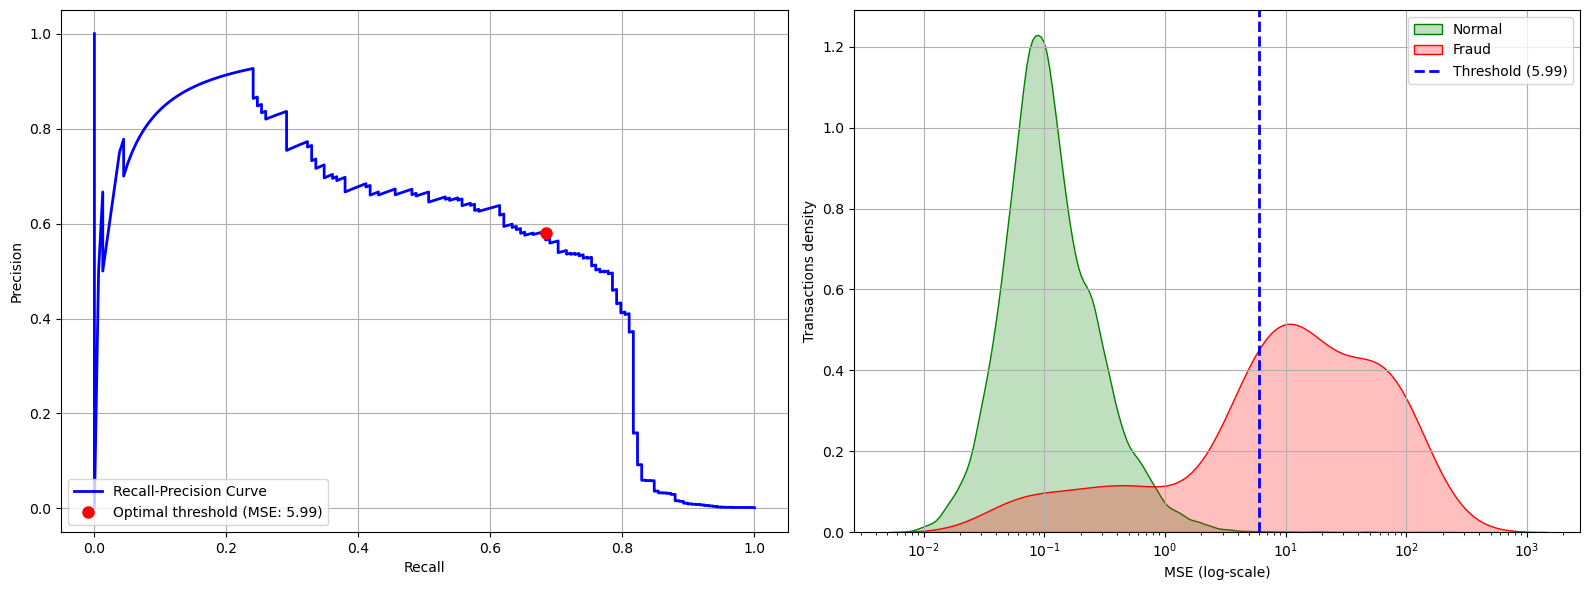

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(recalls, precisions, color='b', lw=2, label='Recall-Precision Curve')
ax1.plot(recalls[best_idx], precisions[best_idx], 'ro', markersize=8, label=f'Optimal threshold (MSE: {best_threshold:.2f})')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.legend(loc="lower left")
ax1.grid(True)

sns.kdeplot(data=df_mse[df_mse['Class'] == 0], x='MSE', fill=True, color='green', label='Normal', ax=ax2, log_scale=True)
sns.kdeplot(data=df_mse[df_mse['Class'] == 1], x='MSE', fill=True, color='red', label='Fraud', ax=ax2, log_scale=True)
ax2.axvline(x=best_threshold, color='blue', linestyle='--', lw=2, label=f'Threshold ({best_threshold:.2f})')
ax2.set_xlabel('MSE (log-scale)')
ax2.set_ylabel('Transactions density')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#### To deploy the model more efficiently, export it from TensorFlow to ONNX. ONNX enables running inference in a lightweight runtime, which can reduce operational costs compared with hosting the model in its original framework.

In [20]:
model.save("autoencoder.keras") # native keras format
model.export("autoencoder_keras") # for use with tf2onnx.convert

INFO:tensorflow:Assets written to: autoencoder_keras/assets
Saved artifact at 'autoencoder_keras'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  139992748733264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748734416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748734032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748734800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748735184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748735376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748734608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992748736336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992351932688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139992351934608: TensorSpec(shap

In [21]:
!python -m tf2onnx.convert --saved-model autoencoder_keras --output autoencoder.onnx --opset 15

2026-07-06 22:28:30,262 - INFO - Using tensorflow=2.19.0, onnx=1.22.0, tf2onnx=1.17.0/None
2026-07-06 22:28:30,262 - INFO - Using opset <onnx, 15>
2026-07-06 22:28:30,268 - INFO - Computed 0 values for constant folding
2026-07-06 22:28:30,280 - INFO - Optimizing ONNX model
2026-07-06 22:28:30,466 - INFO - After optimization: Identity -2 (2->0)
2026-07-06 22:28:30,467 - INFO - 
2026-07-06 22:28:30,467 - INFO - Successfully converted TensorFlow model autoencoder_keras to ONNX
2026-07-06 22:28:30,467 - INFO - Model inputs: ['input_layer']
2026-07-06 22:28:30,467 - INFO - Model outputs: ['output_0']
2026-07-06 22:28:30,467 - INFO - ONNX model is saved at autoencoder.onnx


In [22]:
ort_session = ort.InferenceSession("autoencoder.onnx")
input_name = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name
onnx_input = np.array(X_test_full_scaled, dtype=np.float32)
onnx_output = ort_session.run(None, {input_name: onnx_input})[0]
X_test_pred_onnx = onnx_output
maxdiff = np.max(np.abs(X_test_pred - X_test_pred_onnx))
print(f"max|X_test_pred - X_test_pred_onnx| = {maxdiff:.2e}")

max|X_test_pred - X_test_pred_onnx| = 2.29e-05


In [23]:
np.savetxt("best_threshold", [best_threshold])